# Neural-network learning-rate search: test on 2024
Reads `TEST_TRAIN/train.csv` and `TEST_TRAIN/test.csv` without downloading or rewriting data.
Elections through 2019 form the training input; 2024 is held out for final testing.
All model and preprocessing code is included here; no project modules are imported.

Train five seeds for each learning rate in `[0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 1]` (35 runs).
Each seed holds out half of 2019 for validation and uses the other half plus
all earlier elections for weight updates. The same seed uses the same split,
initial weights, and batch order across learning rates for a fair comparison.

Training and validation use cross-entropy. Every strictly lower validation loss
saves a checkpoint and resets patience, with no minimum improvement threshold.
Stop after 20 consecutive epochs without improvement, or at 1,000 epochs,
and restore the best checkpoint for each run.

Select the learning rate with the lowest mean best validation cross-entropy
across its five seeds (ties follow the candidate order). Validation therefore
controls both checkpoint selection and learning-rate selection; its score is
not an independent estimate of generalisation. Evaluate only the selected
rate's five-network ensemble on 2024. There is no subsequent fit on all rows.

The summary reports `mean_best_validation_loss` across the five seeds for each
learning rate. Test scores include all labelled rows, imputing missing predictors
with each network's fitted preprocessor.


In [1]:
from pathlib import Path
from typing import Any, TypedDict
import copy
import warnings
import numpy as np
from numpy.typing import NDArray
import pandas as pd
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

project_root = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "TEST_TRAIN" / "train.csv").is_file()), None,
)
if project_root is None:
    raise FileNotFoundError("Run this notebook from inside the election project.")
data = pd.read_csv(project_root / "TEST_TRAIN" / "train.csv")
data_years = pd.to_numeric(data["election"], errors="raise")
if data_years.isna().any():
    raise ValueError("Election years must not be missing.")
train = data.loc[data_years <= 2019].copy()
test = pd.read_csv(project_root / "TEST_TRAIN" / "test.csv")
FEATURE_COLUMNS = [
    "country/region",
    "previous_majority_proportion",
    "previous_winner",
    "Conservative",
    "Labour",
    "LD",
    "incumbent",
    "previous_con_share",
    "previous_lib_share",
    "previous_lab_share",
    "previous_natSW_share",
    "projected_con_share",
    "projected_lib_share",
    "projected_lab_share",
]
CATEGORICAL_COLUMNS = ["country/region", "previous_winner", "incumbent"]
NUMERIC_COLUMNS = [
    column for column in FEATURE_COLUMNS if column not in CATEGORICAL_COLUMNS
]
SEEDS = tuple(range(101223, 101228))
BATCH_SIZE = 64
MAX_EPOCHS = 1000
PATIENCE = 20
LEARNING_RATES = (0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0)
HIDDEN_SIZES = (32, 16)

# Small CPU networks avoid unnecessary thread overhead.
torch.set_num_threads(1)
years = pd.to_numeric(train["election"], errors="raise")
if years.isna().any() or (years > 2019).any() or not (years == 2019).any():
    raise ValueError("Expected training elections through 2019, with no later rows.")
if train.empty or train["winner"].isna().any():
    raise ValueError("Training requires nonempty data with known winners.")
evaluation_years = pd.to_numeric(test["election"], errors="raise")
evaluation_data = test.loc[evaluation_years == 2024].dropna(subset=["winner"]).copy()
if evaluation_data.empty:
    raise ValueError("No labelled 2024 test rows.")
print(f"Training input: {len(train)} rows through 2019")
print(f"2024 evaluation: {len(evaluation_data)} labelled rows")


Training input: 5705 rows through 2019
2024 evaluation: 632 labelled rows


In [2]:
def make_preprocessor() -> ColumnTransformer:
    """Create preprocessing to fit on training rows and reuse for prediction."""
    return ColumnTransformer([
        # Fill missing numbers with training medians, then centre and scale them.
        # Keep even entirely missing columns so the feature layout stays stable.
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
        ]), NUMERIC_COLUMNS),
        ("categorical", Pipeline([
            # Treat missing categories as a named category. One-hot encoding makes
            # a separate indicator column for each category seen during fitting;
            # unseen categories at prediction time get all-zero indicators.
            ("impute", SimpleImputer(
                strategy="constant", fill_value="__MISSING__", keep_empty_features=True
            )),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_COLUMNS),
    ])

def as_features(matrix: NDArray[Any] | sparse.spmatrix) -> torch.Tensor:
    """Convert sklearn's feature matrix into a dense float32 PyTorch tensor."""
    # One-hot encoding can produce sparse matrices; these linear layers need dense input.
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    array = np.asarray(matrix, dtype=np.float32)
    # Fail early if preprocessing leaves NaN or infinite values in the predictors.
    if not np.isfinite(array).all():
        raise ValueError("Preprocessed predictors contain non-finite values.")
    return torch.from_numpy(array)

class NeuralNetwork(nn.Module):
    """CPU classifier trained with cross-entropy on raw logits."""

    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        layers = []
        # Each linear layer learns weighted combinations of its inputs. ReLU sets
        # negative outputs to zero, letting the network learn nonlinear patterns.
        for width in HIDDEN_SIZES:
            layers.extend([nn.Linear(input_dim, width), nn.ReLU()])
            input_dim = width
        # Output raw logits for cross-entropy, which applies log-softmax internally.
        # Convert logits to probabilities with softmax only for evaluation.
        layers.append(nn.Linear(input_dim, num_classes))
        self.layers = nn.Sequential(*layers)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # Calling network(X) passes the rows through every layer in sequence.
        return self.layers(X)

class TrainingRecord(TypedDict):
    """Diagnostics for one seeded training run."""

    seed: int
    learning_rate: float
    best_epoch: int | None
    stopping_epoch: int
    best_validation_loss: float | None

def _train_network(
    training: pd.DataFrame, validation: pd.DataFrame | None,
    label_encoder: LabelEncoder, seed: int, epochs: int, learning_rate: float,
) -> tuple[NeuralNetwork, ColumnTransformer, TrainingRecord]:
    """Restore the best checkpoint with validation; otherwise run exactly epochs."""
    preprocessor = make_preprocessor()
    # Learn preprocessing only from training rows to avoid leaking validation data.
    x_train = as_features(preprocessor.fit_transform(training[FEATURE_COLUMNS]))
    # Cross-entropy expects integer class indices and raw network logits.
    y_train = torch.tensor(
        label_encoder.transform(training["winner"]), dtype=torch.long,
    )
    if validation is not None:
        x_validation = as_features(preprocessor.transform(validation[FEATURE_COLUMNS]))
        y_validation = torch.tensor(
            label_encoder.transform(validation["winner"]), dtype=torch.long,
        )

    # Keep initialisation reproducible without changing the caller's RNG state.
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(seed)
        network = NeuralNetwork(x_train.shape[1], len(label_encoder.classes_))
        # Shuffle paired features and labels into batches with a separately seeded
        # generator, making the batch order reproducible for this run.
        loader = DataLoader(
            TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True,
            generator=torch.Generator().manual_seed(seed), num_workers=0,
        )
        optimizer = torch.optim.SGD(network.parameters(), lr=learning_rate, momentum=0.0)
        # Average negative log probability of the winning class over rows.
        criterion = nn.CrossEntropyLoss()
        best_loss = float("inf")
        best_epoch = 0
        best_state = None
        stale_epochs = 0
        for epoch in range(1, epochs + 1):
            network.train()
            for x_batch, y_batch in loader:
                # Clear old gradients, measure this batch's error, differentiate
                # it with respect to the weights, then apply an SGD update.
                optimizer.zero_grad()
                loss = criterion(network(x_batch), y_batch)
                if not torch.isfinite(loss).item():
                    raise RuntimeError(f"Non-finite training loss for seed {seed}, epoch {epoch}")
                loss.backward()
                optimizer.step()
            if validation is None:
                # Refitting uses a fixed duration, with no early-stopping check.
                continue
            # Evaluate held-out rows after each epoch without updating the weights.
            network.eval()
            with torch.inference_mode():
                validation_loss = criterion(
                    network(x_validation), y_validation
                ).item()
            if not np.isfinite(validation_loss):
                raise RuntimeError(f"Non-finite validation loss for seed {seed}, epoch {epoch}")
            if validation_loss < best_loss:
                best_loss = validation_loss
                best_epoch = epoch
                # Copy the weights so later updates cannot change this checkpoint.
                best_state = copy.deepcopy(network.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1
            if stale_epochs >= PATIENCE:
                break
        if validation is not None:
            # Use the best qualifying checkpoint, which can precede the stopping epoch.
            network.load_state_dict(best_state)
        network.eval()
    # Keep diagnostics for inspecting duration selection and subsequent refits.
    record: TrainingRecord = {"seed": seed, "learning_rate": learning_rate, "best_epoch": best_epoch if validation is not None else None,
              "stopping_epoch": epoch,
              "best_validation_loss": best_loss if validation is not None else None}
    return network, preprocessor, record


In [3]:
label_encoder = LabelEncoder().fit(train["winner"])
latest = train.loc[years == years.max()]
historical = train.loc[years < years.max()]
if historical.empty or len(latest) < 2:
    raise ValueError("Need historical elections and at least two latest-election rows.")
counts = latest["winner"].value_counts()
can_stratify = counts.min() >= 2 and len(latest) // 2 >= len(counts)
if not can_stratify:
    warnings.warn("Latest-election class counts do not permit stratification.")

runs_by_learning_rate = {}
all_records = []
for learning_rate in LEARNING_RATES:
    rate_networks, rate_preprocessors, rate_records = [], [], []
    for index, seed in enumerate(SEEDS, start=1):
        # Reuse each seed's split across candidates; 2024 is never used here.
        latest_train, validation = train_test_split(
            latest, test_size=0.5, random_state=seed,
            stratify=latest["winner"] if can_stratify else None,
        )
        training = pd.concat([historical, latest_train])
        network, preprocessor, record = _train_network(
            training, validation, label_encoder, seed, MAX_EPOCHS, learning_rate,
        )
        rate_networks.append(network)
        rate_preprocessors.append(preprocessor)
        rate_records.append(record)
        all_records.append(record)
        print(
            f"Learning rate {learning_rate:g} | network {index}/{len(SEEDS)} | "
            f"seed {seed} | epochs run: {record['stopping_epoch']} | "
            f"best epoch (restored): {record['best_epoch']} | "
            f"best validation cross-entropy: {record['best_validation_loss']:.6f}",
            flush=True,
        )
    runs_by_learning_rate[learning_rate] = {
        "networks": rate_networks,
        "preprocessors": rate_preprocessors,
        "records": rate_records,
    }

training_records = pd.DataFrame(all_records)
learning_rate_summary = training_records.groupby("learning_rate", sort=False).agg(
    mean_best_validation_loss=("best_validation_loss", "mean"),
    std_best_validation_loss=("best_validation_loss", "std"),
    mean_best_epoch=("best_epoch", "mean"),
    runs=("seed", "count"),
)
selected_learning_rate = float(
    learning_rate_summary["mean_best_validation_loss"].idxmin()
)
selected_run = runs_by_learning_rate[selected_learning_rate]
networks = selected_run["networks"]
preprocessors = selected_run["preprocessors"]
records = selected_run["records"]
print(f"Selected learning rate: {selected_learning_rate:g} (lowest mean validation cross-entropy)")
display(learning_rate_summary)
display(training_records)


Learning rate 0.03 | network 1/5 | seed 101223 | epochs run: 124 | best epoch (restored): 104 | best validation cross-entropy: 0.145536
Learning rate 0.03 | network 2/5 | seed 101224 | epochs run: 99 | best epoch (restored): 79 | best validation cross-entropy: 0.210807
Learning rate 0.03 | network 3/5 | seed 101225 | epochs run: 156 | best epoch (restored): 136 | best validation cross-entropy: 0.140908
Learning rate 0.03 | network 4/5 | seed 101226 | epochs run: 160 | best epoch (restored): 140 | best validation cross-entropy: 0.162723
Learning rate 0.03 | network 5/5 | seed 101227 | epochs run: 108 | best epoch (restored): 88 | best validation cross-entropy: 0.166444
Learning rate 0.05 | network 1/5 | seed 101223 | epochs run: 93 | best epoch (restored): 73 | best validation cross-entropy: 0.145471
Learning rate 0.05 | network 2/5 | seed 101224 | epochs run: 85 | best epoch (restored): 65 | best validation cross-entropy: 0.196905
Learning rate 0.05 | network 3/5 | seed 101225 | epochs

,mean_best_validation_loss,std_best_validation_loss,mean_best_epoch,runs
learning_rate,,,,
0.03,0.165283,0.027678,109.4,5
0.05,0.158900,0.022533,83.2,5
0.10,0.150657,0.022288,78.2,5
0.20,0.159246,0.019924,33.4,5
0.30,0.163985,0.019532,16.4,5
0.50,0.164992,0.025993,22.6,5
1.00,0.165222,0.024536,22.0,5


,seed,learning_rate,best_epoch,stopping_epoch,best_validation_loss
0,101223,0.03,104,124,0.145536
1,101224,0.03,79,99,0.210807
2,101225,0.03,136,156,0.140908
3,101226,0.03,140,160,0.162723
4,101227,0.03,88,108,0.166444
5,101223,0.05,73,93,0.145471
6,101224,0.05,65,85,0.196905
7,101225,0.05,66,86,0.140986
8,101226,0.05,140,160,0.149951
9,101227,0.05,72,92,0.161189


## Evaluate the selected ensemble on 2024
Scores include all labelled test rows, using each network's fitted imputer for
missing predictors. These scores do not affect training or learning-rate selection.


2024 accuracy: 60.44% (632 labelled rows)


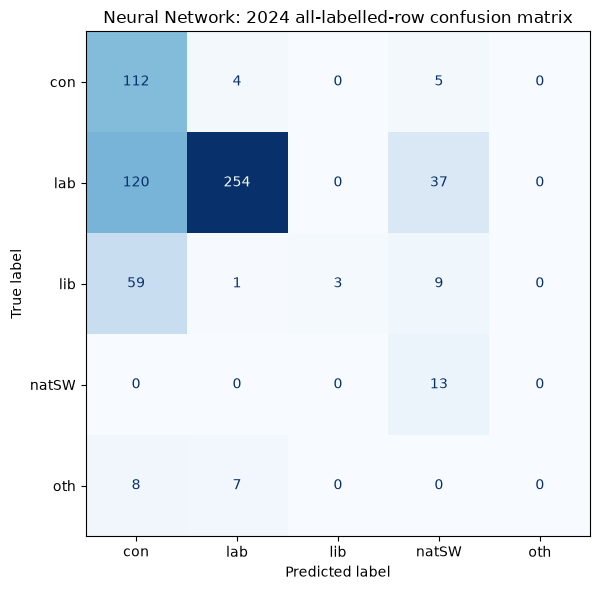

In [4]:
if len(networks) != len(SEEDS):
    raise ValueError("Train all selected learning-rate networks before evaluation.")
probabilities_by_model = []
with torch.inference_mode():
    for network, preprocessor in zip(networks, preprocessors):
        features = as_features(preprocessor.transform(evaluation_data[FEATURE_COLUMNS]))
        network.eval()
        probabilities_by_model.append(torch.softmax(network(features), dim=1).numpy())
ensemble_probabilities = np.mean(probabilities_by_model, axis=0)
ensemble_predictions = label_encoder.inverse_transform(ensemble_probabilities.argmax(axis=1))
all_accuracy = accuracy_score(evaluation_data["winner"], ensemble_predictions)
print(f"2024 accuracy: {all_accuracy:.2%} ({len(evaluation_data)} labelled rows)")
party_labels = sorted(set(evaluation_data["winner"]) | set(ensemble_predictions))
matrix = confusion_matrix(evaluation_data["winner"], ensemble_predictions, labels=party_labels)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(matrix, display_labels=party_labels).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Neural Network: 2024 all-labelled-row confusion matrix")
fig.tight_layout()
plt.show()


## Accuracy on seats that changed party in 2024
A seat changed party when its recorded `winner` differs from `previous_winner`.
Rows without a known previous winner are excluded. Score all remaining changed
seats, including those with imputed predictors, using the ensemble predictions.


In [5]:
changed = (
    evaluation_data["previous_winner"].notna()
    & evaluation_data["previous_winner"].ne(evaluation_data["winner"])
).to_numpy()
count = int(changed.sum())
if count:
    changed_seat_accuracy = accuracy_score(
        evaluation_data.loc[changed, "winner"], ensemble_predictions[changed]
    )
    print(f"2024 changed-seat accuracy: {changed_seat_accuracy:.2%} ({count} seats)")
else:
    changed_seat_accuracy = None
    print("2024 changed-seat accuracy: N/A (0 seats)")


2024 changed-seat accuracy: 21.67% (300 seats)


## Brier score and log loss (cross-entropy)
The multiclass Brier score is the mean, across seats, of the sum over all parties
of squared differences between predicted probabilities and one-hot outcomes.
This uses the unscaled multiclass convention (range 0–2).
Log loss and cross-entropy are the same metric here: the mean negative natural
logarithm of the actual winner's probability. Lower is better for both metrics.
An unseen winning party receives probability zero; log loss clips probabilities
to float64 machine epsilon to avoid infinite values. Metrics use all labelled
2024 test rows, including those with imputed predictors.


In [6]:
import numpy as np


def probability_scores(winners, probabilities, classes):
    """Mean multiclass Brier score and cross-entropy, with natural logarithms."""
    # Include unseen winning parties with predicted probability zero.
    labels = list(classes)
    labels += [label for label in pd.unique(np.asarray(winners)) if label not in labels]
    probability_table = pd.DataFrame(
        np.asarray(probabilities, dtype=float), columns=classes
    ).reindex(columns=labels, fill_value=0.0)
    probabilities = probability_table.to_numpy()
    winner_columns = pd.Index(labels).get_indexer(np.asarray(winners))
    targets = np.eye(len(labels))[winner_columns]
    brier = float(np.mean(np.sum((probabilities - targets) ** 2, axis=1)))
    winning_probabilities = probabilities[np.arange(len(winner_columns)), winner_columns]
    # Clip zero probabilities to keep log loss finite, including unseen winners.
    log_loss = float(-np.mean(np.log(np.clip(
        winning_probabilities, np.finfo(float).eps, 1.0
    ))))
    return {"brier_score": brier, "log_loss_cross_entropy": log_loss}

# Score all labelled test rows in label-encoder class order.
probability_metrics = probability_scores(
    evaluation_data["winner"], ensemble_probabilities, label_encoder.classes_,
)
print(f"2024 probability metrics ({len(evaluation_data)} labelled seats):")
print(f"  Brier score: {probability_metrics['brier_score']:.6f}")
print(f"  Log loss (cross-entropy): {probability_metrics['log_loss_cross_entropy']:.6f}")


2024 probability metrics (632 labelled seats):
  Brier score: 0.651815
  Log loss (cross-entropy): 1.970251
